In [ ]:
"""
================================================================
FACE EXTRACTION FOR ENROLLMENT — Google Colab Edition
================================================================
Model  : buffalo_l  (RetinaFace detector + ArcFace w600k_r50)
Align  : Official 5-point norm_crop (matches ArcFace training)
Output : 112×112 aligned crops + 512-D embeddings + gallery

Usage  : Run each section as a separate Colab cell, or run all.
================================================================
"""

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL DEPENDENCIES  (run once per session)       ║
# ╚════════════════════════════════════════════════════════════════╝

import subprocess
import sys

def install_packages():
    """Install required packages if not already present."""
    packages = {
        'insightface': 'insightface',
        'onnxruntime': None,  # handled separately for GPU
        'cv2': 'opencv-python',
        'tqdm': 'tqdm',
    }
    for module, pip_name in packages.items():
        if pip_name is None:
            continue
        try:
            __import__(module)
        except ImportError:
            print(f"Installing {pip_name}...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

    # Handle onnxruntime: prefer GPU version, fallback to CPU
    try:
        import onnxruntime as ort
        if 'CUDAExecutionProvider' not in ort.get_available_providers():
            raise ImportError("No CUDA provider")
        print("✓ onnxruntime-gpu already available")
    except (ImportError, Exception):
        print("Installing onnxruntime-gpu...")
        try:
            subprocess.check_call([
                sys.executable, '-m', 'pip', 'install', '-q', 'onnxruntime-gpu'
            ])
        except Exception:
            print("GPU runtime failed, installing CPU version...")
            subprocess.check_call([
                sys.executable, '-m', 'pip', 'install', '-q', 'onnxruntime'
            ])

install_packages()
print("✓ All dependencies ready")



✓ onnxruntime-gpu already available
✓ All dependencies ready


In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — MOUNT GOOGLE DRIVE                                 ║
# ╚════════════════════════════════════════════════════════════════╝

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
    print("✓ Google Drive mounted")
except ImportError:
    IN_COLAB = False
    print("Not running in Colab — skipping Drive mount")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted


In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — DETECT HARDWARE (GPU / CPU)                        ║
# ╚════════════════════════════════════════════════════════════════╝

import onnxruntime as ort

available_providers = ort.get_available_providers()
HAS_GPU = 'CUDAExecutionProvider' in available_providers

if HAS_GPU:
    PROVIDERS = ['CUDAExecutionProvider', 'CPUExecutionProvider']
    # Show GPU info
    try:
        import subprocess
        gpu_info = subprocess.check_output(['nvidia-smi', '--query-gpu=name,memory.total',
                                            '--format=csv,noheader']).decode().strip()
        print(f"✓ GPU detected: {gpu_info}")
    except Exception:
        print("✓ GPU detected (CUDAExecutionProvider available)")
else:
    PROVIDERS = ['CPUExecutionProvider']
    print("⚠ No GPU detected — running on CPU (slower but works fine)")

print(f"  ONNX providers: {available_providers}")
print(f"  Using: {PROVIDERS}")



✓ GPU detected: Tesla T4, 15360 MiB
  ONNX providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
  Using: ['CUDAExecutionProvider', 'CPUExecutionProvider']


In [ ]:
# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — CONFIGURATION  (edit paths & params here)          ║
# ╚════════════════════════════════════════════════════════════════╝

import os

# ─── PATHS ────────────────────────────────────────────────────
# *** EDIT THESE TO MATCH YOUR GOOGLE DRIVE STRUCTURE ***

VIDEO_DIR    = "/content/drive/MyDrive/Final_Project/dataset/enrollment/phone_videos"
OUTPUT_BASE  = "/content/drive/MyDrive/Final_Project/dataset/enrollment"

# Auto-created output subdirectories
FACES_DIR      = os.path.join(OUTPUT_BASE, "faces_aligned")
EMBEDDINGS_DIR = os.path.join(OUTPUT_BASE, "embeddings")
GALLERY_DIR    = os.path.join(OUTPUT_BASE, "gallery")
DEBUG_DIR      = os.path.join(OUTPUT_BASE, "debug_frames")

# ─── FRAME SAMPLING ──────────────────────────────────────────
EXTRACT_INTERVAL_SECONDS = 0.25    # 4 frames per second from video

# ─── DETECTION (RetinaFace) ──────────────────────────────────
DET_SIZE   = (640, 640)            # Detector resolution
DET_THRESH = 0.5                   # Internal detector threshold

# ─── QUALITY FILTERING ───────────────────────────────────────
MIN_DET_SCORE      = 0.6           # Minimum confidence to keep a face
MIN_FACE_SIZE      = 50            # Minimum face bbox side (pixels)
MAX_FACES_PER_FRAME = 1            # Enrollment = single person per video
MIN_EYE_DISTANCE   = 15            # Pixels between eyes
MAX_ROLL_ANGLE     = 30            # Max head tilt (degrees)
MAX_YAW_PROXY      = 0.35          # Nose offset ratio (proxy for head turn)
MIN_FACE_AREA_RATIO = 0.005        # Face area / frame area
EDGE_MARGIN        = 10            # Reject faces near frame border

# ─── DUPLICATE REMOVAL ───────────────────────────────────────
ENABLE_DUPLICATE_REMOVAL = True
DUPLICATE_COSINE_THRESH  = 0.95    # Above this = same frame, skip

# ─── OUTPUT OPTIONS ──────────────────────────────────────────
SAVE_DEBUG_FRAMES = False           # Set True to see annotated frames
IMAGE_QUALITY     = 95              # JPEG quality for saved crops

print("✓ Configuration loaded")
print(f"  Video source : {VIDEO_DIR}")
print(f"  Output base  : {OUTPUT_BASE}")



✓ Configuration loaded
  Video source : /content/drive/MyDrive/Final_Project/dataset/enrollment/phone_videos
  Output base  : /content/drive/MyDrive/Final_Project/dataset/enrollment


In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — LOAD MODEL                                         ║
# ╚════════════════════════════════════════════════════════════════╝

import cv2
import numpy as np
import json
import pickle
import logging
from datetime import datetime
from collections import defaultdict
from tqdm import tqdm

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('insightface').setLevel(logging.ERROR)

from insightface.app import FaceAnalysis
from insightface.utils.face_align import norm_crop   # Official 5-point alignment

print("=" * 65)
print("  FACE ENROLLMENT EXTRACTOR v2 — Colab Edition")
print("  Model : buffalo_l (RetinaFace + ArcFace w600k_r50)")
print("  Align : 5-point norm_crop (official InsightFace)")
print("  Device:", "GPU 🚀" if HAS_GPU else "CPU 🐢")
print("=" * 65)

app = FaceAnalysis(
    name='buffalo_l',
    providers=PROVIDERS,
    allowed_modules=['detection', 'recognition']   # skip age/gender → faster
)

app.prepare(
    ctx_id=0 if HAS_GPU else -1,
    det_size=DET_SIZE,
    det_thresh=DET_THRESH
)

print("✓ Model loaded and ready")


  FACE ENROLLMENT EXTRACTOR v2 — Colab Edition
  Model : buffalo_l (RetinaFace + ArcFace w600k_r50)
  Align : 5-point norm_crop (official InsightFace)
  Device: GPU 🚀
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: 

In [ ]:



# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — CORE FUNCTIONS                                     ║
# ╚════════════════════════════════════════════════════════════════╝

# ── Quality Check ────────────────────────────────────────────

def check_face_quality(face, frame_shape):
    """
    Run all quality checks on one detected face.

    Returns (passed: bool, reason: str)
    """
    bbox = face.bbox.astype(int)
    kps  = face.kps                     # 5 landmarks
    score = face.det_score
    fh, fw = frame_shape[:2]
    x1, y1, x2, y2 = bbox
    face_w, face_h = x2 - x1, y2 - y1

    # 1 — confidence
    if score < MIN_DET_SCORE:
        return False, f"low_conf_{score:.2f}"

    # 2 — minimum size
    if face_w < MIN_FACE_SIZE or face_h < MIN_FACE_SIZE:
        return False, f"too_small_{face_w}x{face_h}"

    # 3 — face area relative to frame
    if (face_w * face_h) / (fw * fh) < MIN_FACE_AREA_RATIO:
        return False, "area_too_small"

    # 4 — not cut off at edges
    if x1 < EDGE_MARGIN or y1 < EDGE_MARGIN or x2 > fw - EDGE_MARGIN or y2 > fh - EDGE_MARGIN:
        return False, "at_edge"

    # 5 — landmarks must exist
    if kps is None:
        return False, "no_landmarks"

    left_eye, right_eye, nose, mouth_l, mouth_r = kps[0], kps[1], kps[2], kps[3], kps[4]

    # 6 — eye distance
    eye_dist = np.linalg.norm(right_eye - left_eye)
    if eye_dist < MIN_EYE_DISTANCE:
        return False, f"eye_dist_{eye_dist:.1f}"

    # 7 — roll (head tilt)
    roll = abs(np.degrees(np.arctan2(right_eye[1] - left_eye[1],
                                      right_eye[0] - left_eye[0])))
    if roll > MAX_ROLL_ANGLE:
        return False, f"roll_{roll:.1f}"

    # 8 — yaw proxy (nose off-center from eyes = head turned)
    eye_cx = (left_eye[0] + right_eye[0]) / 2.0
    nose_offset = abs(nose[0] - eye_cx) / eye_dist
    if nose_offset > MAX_YAW_PROXY:
        return False, f"yaw_{nose_offset:.2f}"

    # 9 — sanity: mouth below nose
    if mouth_l[1] < nose[1] or mouth_r[1] < nose[1]:
        return False, "bad_landmarks"

    # 10 — embedding exists
    if not hasattr(face, 'embedding') or face.embedding is None:
        return False, "no_embedding"

    return True, "passed"


# ── Duplicate Removal ────────────────────────────────────────

def remove_duplicates(embeddings_list, face_data_list):
    """Remove near-identical frames by cosine similarity."""
    if not ENABLE_DUPLICATE_REMOVAL or len(embeddings_list) <= 1:
        return embeddings_list, face_data_list

    embs = np.array(embeddings_list)
    n = len(embs)
    keep = np.ones(n, dtype=bool)

    for i in range(n):
        if not keep[i]:
            continue
        for j in range(i + 1, n):
            if not keep[j]:
                continue
            if np.dot(embs[i], embs[j]) > DUPLICATE_COSINE_THRESH:
                keep[j] = False

    kept = np.where(keep)[0]
    removed = n - len(kept)
    if removed > 0:
        print(f"    [DEDUP] Removed {removed} near-duplicates, kept {len(kept)}")

    return [embeddings_list[i] for i in kept], [face_data_list[i] for i in kept]


# ── Debug Frame Saver ────────────────────────────────────────

def save_debug_frame(frame, face, person_id, frame_idx, passed, reason):
    """Annotate and save frame for visual debugging."""
    if not SAVE_DEBUG_FRAMES:
        return
    d_dir = os.path.join(DEBUG_DIR, person_id)
    os.makedirs(d_dir, exist_ok=True)

    img = frame.copy()
    b = face.bbox.astype(int)
    color = (0, 255, 0) if passed else (0, 0, 255)
    cv2.rectangle(img, (b[0], b[1]), (b[2], b[3]), color, 2)

    if face.kps is not None:
        colors_lm = [(0,255,0),(0,255,0),(255,255,0),(255,0,0),(255,0,0)]
        for i, (x, y) in enumerate(face.kps.astype(int)):
            cv2.circle(img, (x, y), 3, colors_lm[i], -1)

    cv2.putText(img, f"{face.det_score:.2f}|{reason}",
                (b[0], b[1]-8), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    cv2.imwrite(os.path.join(d_dir, f"f{frame_idx:06d}_{reason}.jpg"), img)


# ── Save Per-Person Data ─────────────────────────────────────

def save_person_data(person_id, embeddings_list, face_data_list):
    """
    Save aligned crops, embeddings, centroid, metadata for one person.
    Returns number of faces saved.
    """
    if len(embeddings_list) == 0:
        print(f"    ⚠ No faces to save for {person_id}")
        return 0

    # Directories
    face_dir = os.path.join(FACES_DIR, person_id)
    emb_dir  = os.path.join(EMBEDDINGS_DIR, person_id)
    os.makedirs(face_dir, exist_ok=True)
    os.makedirs(emb_dir, exist_ok=True)
    os.makedirs(GALLERY_DIR, exist_ok=True)

    # Save aligned face crops
    enc = [int(cv2.IMWRITE_JPEG_QUALITY), IMAGE_QUALITY]
    for i, data in enumerate(face_data_list):
        cv2.imwrite(os.path.join(face_dir, f"{person_id}_{i:04d}.jpg"),
                     data['aligned_face'], enc)

    # Embeddings matrix
    emb_array = np.array(embeddings_list)                       # (N, 512)
    np.save(os.path.join(emb_dir, f"{person_id}_embeddings.npy"), emb_array)

    # Centroid (mean embedding, re-normalized)
    centroid = np.mean(emb_array, axis=0)
    centroid = centroid / np.linalg.norm(centroid)

    # Intra-person similarity (quality metric)
    sims = emb_array @ centroid
    intra_mean = float(np.mean(sims))
    intra_min  = float(np.min(sims))
    intra_std  = float(np.std(sims))

    # Gallery file for this person
    np.savez(os.path.join(GALLERY_DIR, f"{person_id}_gallery.npz"),
             centroid=centroid, embeddings=emb_array)

    # Metadata JSON
    meta = {
        'person_id': person_id,
        'num_faces': len(embeddings_list),
        'embedding_dim': int(emb_array.shape[1]),
        'intra_similarity_mean': round(intra_mean, 4),
        'intra_similarity_min':  round(intra_min, 4),
        'intra_similarity_std':  round(intra_std, 4),
        'det_scores': [round(d['det_score'], 3) for d in face_data_list],
        'images': [f"{person_id}_{i:04d}.jpg" for i in range(len(face_data_list))],
        'extraction_date': datetime.now().isoformat(),
    }
    with open(os.path.join(emb_dir, f"{person_id}_metadata.json"), 'w') as f:
        json.dump(meta, f, indent=2)

    # Print quality report
    print(f"    Intra-person cosine sim: mean={intra_mean:.3f} | "
          f"min={intra_min:.3f} | std={intra_std:.3f}")
    if intra_mean < 0.5:
        print(f"    ⚠ LOW consistency — check for mixed identities or bad crops")
    elif intra_mean >= 0.7:
        print(f"    ✓ High consistency — good enrollment quality")

    return len(embeddings_list)



In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — MAIN EXTRACTION FUNCTION                           ║
# ╚════════════════════════════════════════════════════════════════╝

def extract_faces_from_video(video_path, person_id):
    """
    Full pipeline for one enrollment video:
      Frame → RetinaFace detect → Quality filter → 5-pt norm_crop align
      → ArcFace embedding → Dedup → Save crops + embeddings + gallery
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"  ❌ Cannot open: {video_path}")
        return None

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps > 0 else 0
    frame_interval = max(1, int(fps * EXTRACT_INTERVAL_SECONDS))

    print(f"\n  {'─'*55}")
    print(f"  Person   : {person_id}")
    print(f"  Video    : {os.path.basename(video_path)}")
    print(f"  Duration : {duration:.1f}s | FPS: {fps:.1f} | "
          f"Total: {total_frames} | Sample every {frame_interval} frames")
    print(f"  {'─'*55}")

    embeddings_list = []
    face_data_list  = []
    stats = defaultdict(int)
    stats['frames_total']   = total_frames
    stats['frames_sampled'] = 0

    frame_idx = 0
    pbar = tqdm(total=total_frames, desc=f"    {person_id}",
                unit="fr", leave=True, ncols=90)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_interval == 0:
            stats['frames_sampled'] += 1

            # ── Detect + Embed (single call) ──
            # app.get() internally does:
            #   1. RetinaFace detection → bbox + 5 landmarks
            #   2. 5-point norm_crop alignment (112×112)
            #   3. ArcFace forward pass → 512-D embedding
            faces = app.get(frame)

            if len(faces) == 0:
                stats['no_detection'] += 1
                pbar.update(frame_interval)
                frame_idx += 1
                continue

            if len(faces) > MAX_FACES_PER_FRAME:
                stats['multiple_faces'] += 1
                pbar.update(frame_interval)
                frame_idx += 1
                continue

            face = faces[0]

            # ── Quality Check ──
            passed, reason = check_face_quality(face, frame.shape)
            save_debug_frame(frame, face, person_id, frame_idx, passed, reason)

            if not passed:
                stats[reason.split('_')[0]] += 1
                pbar.update(frame_interval)
                frame_idx += 1
                continue

            # ── Align with official 5-point norm_crop ──
            # Uses ALL 5 landmarks mapped to the EXACT reference template
            # (arcface_dst) that ArcFace w600k_r50 was trained with.
            aligned_face = norm_crop(frame, face.kps, image_size=112, mode='arcface')

            # ── Embedding (already computed by app.get) ──
            embedding = face.embedding.copy()
            embedding = embedding / np.linalg.norm(embedding)   # L2-normalize

            embeddings_list.append(embedding)
            face_data_list.append({
                'aligned_face': aligned_face,
                'det_score':    float(face.det_score),
                'bbox':         face.bbox.tolist(),
                'landmarks':    face.kps.tolist(),
                'frame_idx':    frame_idx,
            })
            stats['passed'] += 1

        pbar.update(1)
        frame_idx += 1

    pbar.close()
    cap.release()

    # ── Duplicate removal ──
    pre_dedup = len(embeddings_list)
    embeddings_list, face_data_list = remove_duplicates(embeddings_list, face_data_list)
    stats['duplicates_removed'] = pre_dedup - len(embeddings_list)

    # ── Save everything ──
    num_saved = save_person_data(person_id, embeddings_list, face_data_list)
    stats['final_saved'] = num_saved

    # ── Stats ──
    print(f"\n    ✓ Saved: {num_saved} faces")
    print(f"    Rejections:")
    reject_keys = [
        ('no_detection',   'No detection'),
        ('multiple_faces', 'Multiple faces'),
        ('low',            'Low confidence'),
        ('too',            'Too small'),
        ('area',           'Area too small'),
        ('at',             'At edge'),
        ('eye',            'Eye distance'),
        ('roll',           'Head roll'),
        ('yaw',            'Head yaw'),
        ('bad',            'Bad landmarks'),
        ('no',             'No embedding'),
        ('duplicates_removed', 'Duplicates'),
    ]
    for key, label in reject_keys:
        val = stats.get(key, 0)
        if val > 0:
            print(f"      {label:20s}: {val}")

    if num_saved < 20:
        print(f"\n    ⚠ Only {num_saved} faces! Suggestions:")
        print(f"      → Lower MIN_DET_SCORE (now {MIN_DET_SCORE})")
        print(f"      → Lower MIN_FACE_SIZE (now {MIN_FACE_SIZE})")
        print(f"      → Increase MAX_ROLL_ANGLE (now {MAX_ROLL_ANGLE}°)")
        print(f"      → Decrease EXTRACT_INTERVAL_SECONDS (now {EXTRACT_INTERVAL_SECONDS}s)")
    elif num_saved >= 30:
        print(f"    ✓ Good enrollment — {num_saved} unique faces")

    return dict(stats)



In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — BUILD COMBINED GALLERY                             ║
# ╚════════════════════════════════════════════════════════════════╝

def build_combined_gallery():
    """
    Merge all per-person gallery files into one enrollment_gallery.pkl
    and run cross-person similarity sanity check.
    """
    gallery_files = sorted([
        f for f in os.listdir(GALLERY_DIR) if f.endswith('_gallery.npz')
    ])

    gallery = {}
    for gf in gallery_files:
        pid = gf.replace('_gallery.npz', '')
        data = np.load(os.path.join(GALLERY_DIR, gf))
        gallery[pid] = {
            'centroid':   data['centroid'],
            'embeddings': data['embeddings'],
        }

    # Save combined
    combined_path = os.path.join(GALLERY_DIR, "enrollment_gallery.pkl")
    with open(combined_path, 'wb') as f:
        pickle.dump(gallery, f)

    print(f"\n  ✓ Combined gallery: {combined_path}")
    print(f"    Persons enrolled: {len(gallery)}")
    for pid, d in gallery.items():
        print(f"      {pid}: {d['embeddings'].shape[0]} embeddings")

    # Cross-person similarity check
    pids = list(gallery.keys())
    if len(pids) >= 2:
        print(f"\n  Cross-person similarity (should be < 0.3):")
        for i in range(len(pids)):
            for j in range(i + 1, len(pids)):
                sim = float(np.dot(gallery[pids[i]]['centroid'],
                                   gallery[pids[j]]['centroid']))
                flag = "✓" if sim < 0.3 else "⚠" if sim < 0.45 else "❌"
                print(f"      {pids[i]} ↔ {pids[j]}: {sim:.4f}  {flag}")

    return gallery



In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — RUN EXTRACTION                                     ║
# ╚════════════════════════════════════════════════════════════════╝

def run_extraction():
    """Main entry point — process all videos."""

    # Verify paths
    if not os.path.exists(VIDEO_DIR):
        print(f"❌ Video directory not found: {VIDEO_DIR}")
        print(f"   Make sure Google Drive is mounted and path is correct.")
        return

    video_files = sorted([
        f for f in os.listdir(VIDEO_DIR)
        if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv', '.webm'))
    ])

    if not video_files:
        print(f"❌ No video files in {VIDEO_DIR}")
        return

    # Config summary
    print(f"\n{'═'*65}")
    print(f"  EXTRACTION CONFIG")
    print(f"{'═'*65}")
    print(f"  Device          : {'GPU 🚀' if HAS_GPU else 'CPU 🐢'}")
    print(f"  Model           : buffalo_l (RetinaFace + ArcFace w600k_r50)")
    print(f"  Alignment       : 5-point norm_crop (official)")
    print(f"  Videos found    : {len(video_files)}")
    print(f"  Det size        : {DET_SIZE}")
    print(f"  Det thresh      : {DET_THRESH}")
    print(f"  Min det score   : {MIN_DET_SCORE}")
    print(f"  Min face size   : {MIN_FACE_SIZE}px")
    print(f"  Max roll        : {MAX_ROLL_ANGLE}°")
    print(f"  Max yaw proxy   : {MAX_YAW_PROXY}")
    print(f"  Sample interval : {EXTRACT_INTERVAL_SECONDS}s")
    print(f"  Dedup threshold : {DUPLICATE_COSINE_THRESH}")
    print(f"  Debug frames    : {SAVE_DEBUG_FRAMES}")
    print(f"{'═'*65}")

    all_stats = {}

    for i, vf in enumerate(video_files, 1):
        person_id  = os.path.splitext(vf)[0]
        video_path = os.path.join(VIDEO_DIR, vf)

        print(f"\n{'━'*65}")
        print(f"  VIDEO {i}/{len(video_files)}: {vf}")
        print(f"{'━'*65}")

        try:
            stats = extract_faces_from_video(video_path, person_id)
            if stats:
                all_stats[person_id] = stats
        except Exception as e:
            print(f"\n  ❌ Error processing {vf}: {e}")
            import traceback
            traceback.print_exc()

    # Build gallery
    print(f"\n{'━'*65}")
    print(f"  BUILDING ENROLLMENT GALLERY")
    print(f"{'━'*65}")
    gallery = build_combined_gallery()

    # Final summary
    total_faces = sum(s.get('final_saved', 0) for s in all_stats.values())
    print(f"\n{'═'*65}")
    print(f"  ✅  ENROLLMENT COMPLETE")
    print(f"{'═'*65}")
    print(f"  Videos processed : {len(all_stats)}/{len(video_files)}")
    print(f"  Total faces      : {total_faces}")
    print(f"  Avg per person   : {total_faces / max(len(all_stats), 1):.1f}")
    print(f"")
    print(f"  📁 Output:")
    print(f"     Aligned faces : {FACES_DIR}")
    print(f"     Embeddings    : {EMBEDDINGS_DIR}")
    print(f"     Gallery       : {GALLERY_DIR}")
    if SAVE_DEBUG_FRAMES:
        print(f"     Debug frames  : {DEBUG_DIR}")
    print(f"{'═'*65}")

    return all_stats


# ── RUN IT ──
all_stats = run_extraction()




═════════════════════════════════════════════════════════════════
  EXTRACTION CONFIG
═════════════════════════════════════════════════════════════════
  Device          : GPU 🚀
  Model           : buffalo_l (RetinaFace + ArcFace w600k_r50)
  Alignment       : 5-point norm_crop (official)
  Videos found    : 14
  Det size        : (640, 640)
  Det thresh      : 0.5
  Min det score   : 0.6
  Min face size   : 50px
  Max roll        : 30°
  Max yaw proxy   : 0.35
  Sample interval : 0.25s
  Dedup threshold : 0.95
  Debug frames    : False
═════════════════════════════════════════════════════════════════

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIDEO 1/14: 780306.mp4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ───────────────────────────────────────────────────────
  Person   : 780306
  Video    : 780306.mp4
  Duration : 12.0s | FPS: 29.9 | Total: 358 | Sample every 7 frames
  ───────────────────────────────────────────────────────


    780306: 436fr [00:03, 113.41fr/s]


    [DEDUP] Removed 7 near-duplicates, kept 32
    Intra-person cosine sim: mean=0.887 | min=0.758 | std=0.059
    ✓ High consistency — good enrollment quality

    ✓ Saved: 32 faces
    Rejections:
      Multiple faces      : 2
      Head yaw            : 11
      Duplicates          : 7
    ✓ Good enrollment — 32 unique faces

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIDEO 2/14: 780309.mp4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ───────────────────────────────────────────────────────
  Person   : 780309
  Video    : 780309.mp4
  Duration : 9.1s | FPS: 29.6 | Total: 268 | Sample every 7 frames
  ───────────────────────────────────────────────────────


    780309: 322fr [00:05, 64.26fr/s]


    [DEDUP] Removed 7 near-duplicates, kept 23
    Intra-person cosine sim: mean=0.869 | min=0.646 | std=0.091
    ✓ High consistency — good enrollment quality

    ✓ Saved: 23 faces
    Rejections:
      At edge             : 5
      Head yaw            : 4
      Duplicates          : 7

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIDEO 3/14: 780312.mp4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ───────────────────────────────────────────────────────
  Person   : 780312
  Video    : 780312.mp4
  Duration : 16.9s | FPS: 30.0 | Total: 506 | Sample every 7 frames
  ───────────────────────────────────────────────────────


...

    [DEDUP] Removed 11 near-duplicates, kept 28
    Intra-person cosine sim: mean=0.888 | min=0.753 | std=0.058
    ✓ High consistency — good enrollment quality

    ✓ Saved: 28 faces
    Rejections:
      Head yaw            : 18
      Duplicates          : 11

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIDEO 13/14: 780343.mp4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ───────────────────────────────────────────────────────
  Person   : 780343
  Video    : 780343.mp4
  Duration : 8.3s | FPS: 30.0 | Total: 248 | Sample every 7 frames
  ───────────────────────────────────────────────────────


    780343: 398fr [00:04, 97.73fr/s] 


    [DEDUP] Removed 5 near-duplicates, kept 6
    Intra-person cosine sim: mean=0.928 | min=0.892 | std=0.028
    ✓ High consistency — good enrollment quality

    ✓ Saved: 6 faces
    Rejections:
      No detection        : 4
      Multiple faces      : 7
      Area too small      : 2
      At edge             : 2
      Eye distance        : 5
      Head roll           : 1
      Head yaw            : 4
      Duplicates          : 5

    ⚠ Only 6 faces! Suggestions:
      → Lower MIN_DET_SCORE (now 0.6)
      → Lower MIN_FACE_SIZE (now 50)
      → Increase MAX_ROLL_ANGLE (now 30°)
      → Decrease EXTRACT_INTERVAL_SECONDS (now 0.25s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  VIDEO 14/14: 780349.mp4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ───────────────────────────────────────────────────────
  Person   : 780349
  Video    : 780349.mp4
  Duration : 16.4s | FPS: 30.0 | Total: 491 | Sample every 7 frames
  ──────────────────────────

    780349: 605fr [00:03, 184.79fr/s]


    [DEDUP] Removed 17 near-duplicates, kept 35
    Intra-person cosine sim: mean=0.899 | min=0.788 | std=0.038
    ✓ High consistency — good enrollment quality

    ✓ Saved: 35 faces
    Rejections:
      Head yaw            : 19
      Duplicates          : 17
    ✓ Good enrollment — 35 unique faces

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BUILDING ENROLLMENT GALLERY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ✓ Combined gallery: /content/drive/MyDrive/Final_Project/dataset/enrollment/gallery/enrollment_gallery.pkl
    Persons enrolled: 14
      780306: 32 embeddings
      780309: 23 embeddings
      780312: 60 embeddings
      780314: 112 embeddings
      780315: 30 embeddings
      780317: 147 embeddings
      780322: 40 embeddings
      780324: 50 embeddings
      780328: 45 embeddings
      780339: 61 embeddings
      780340: 38 embeddings
      780341: 28 embeddings
      780343: 6 embeddings
      780349: 35 embeddings

  Cros

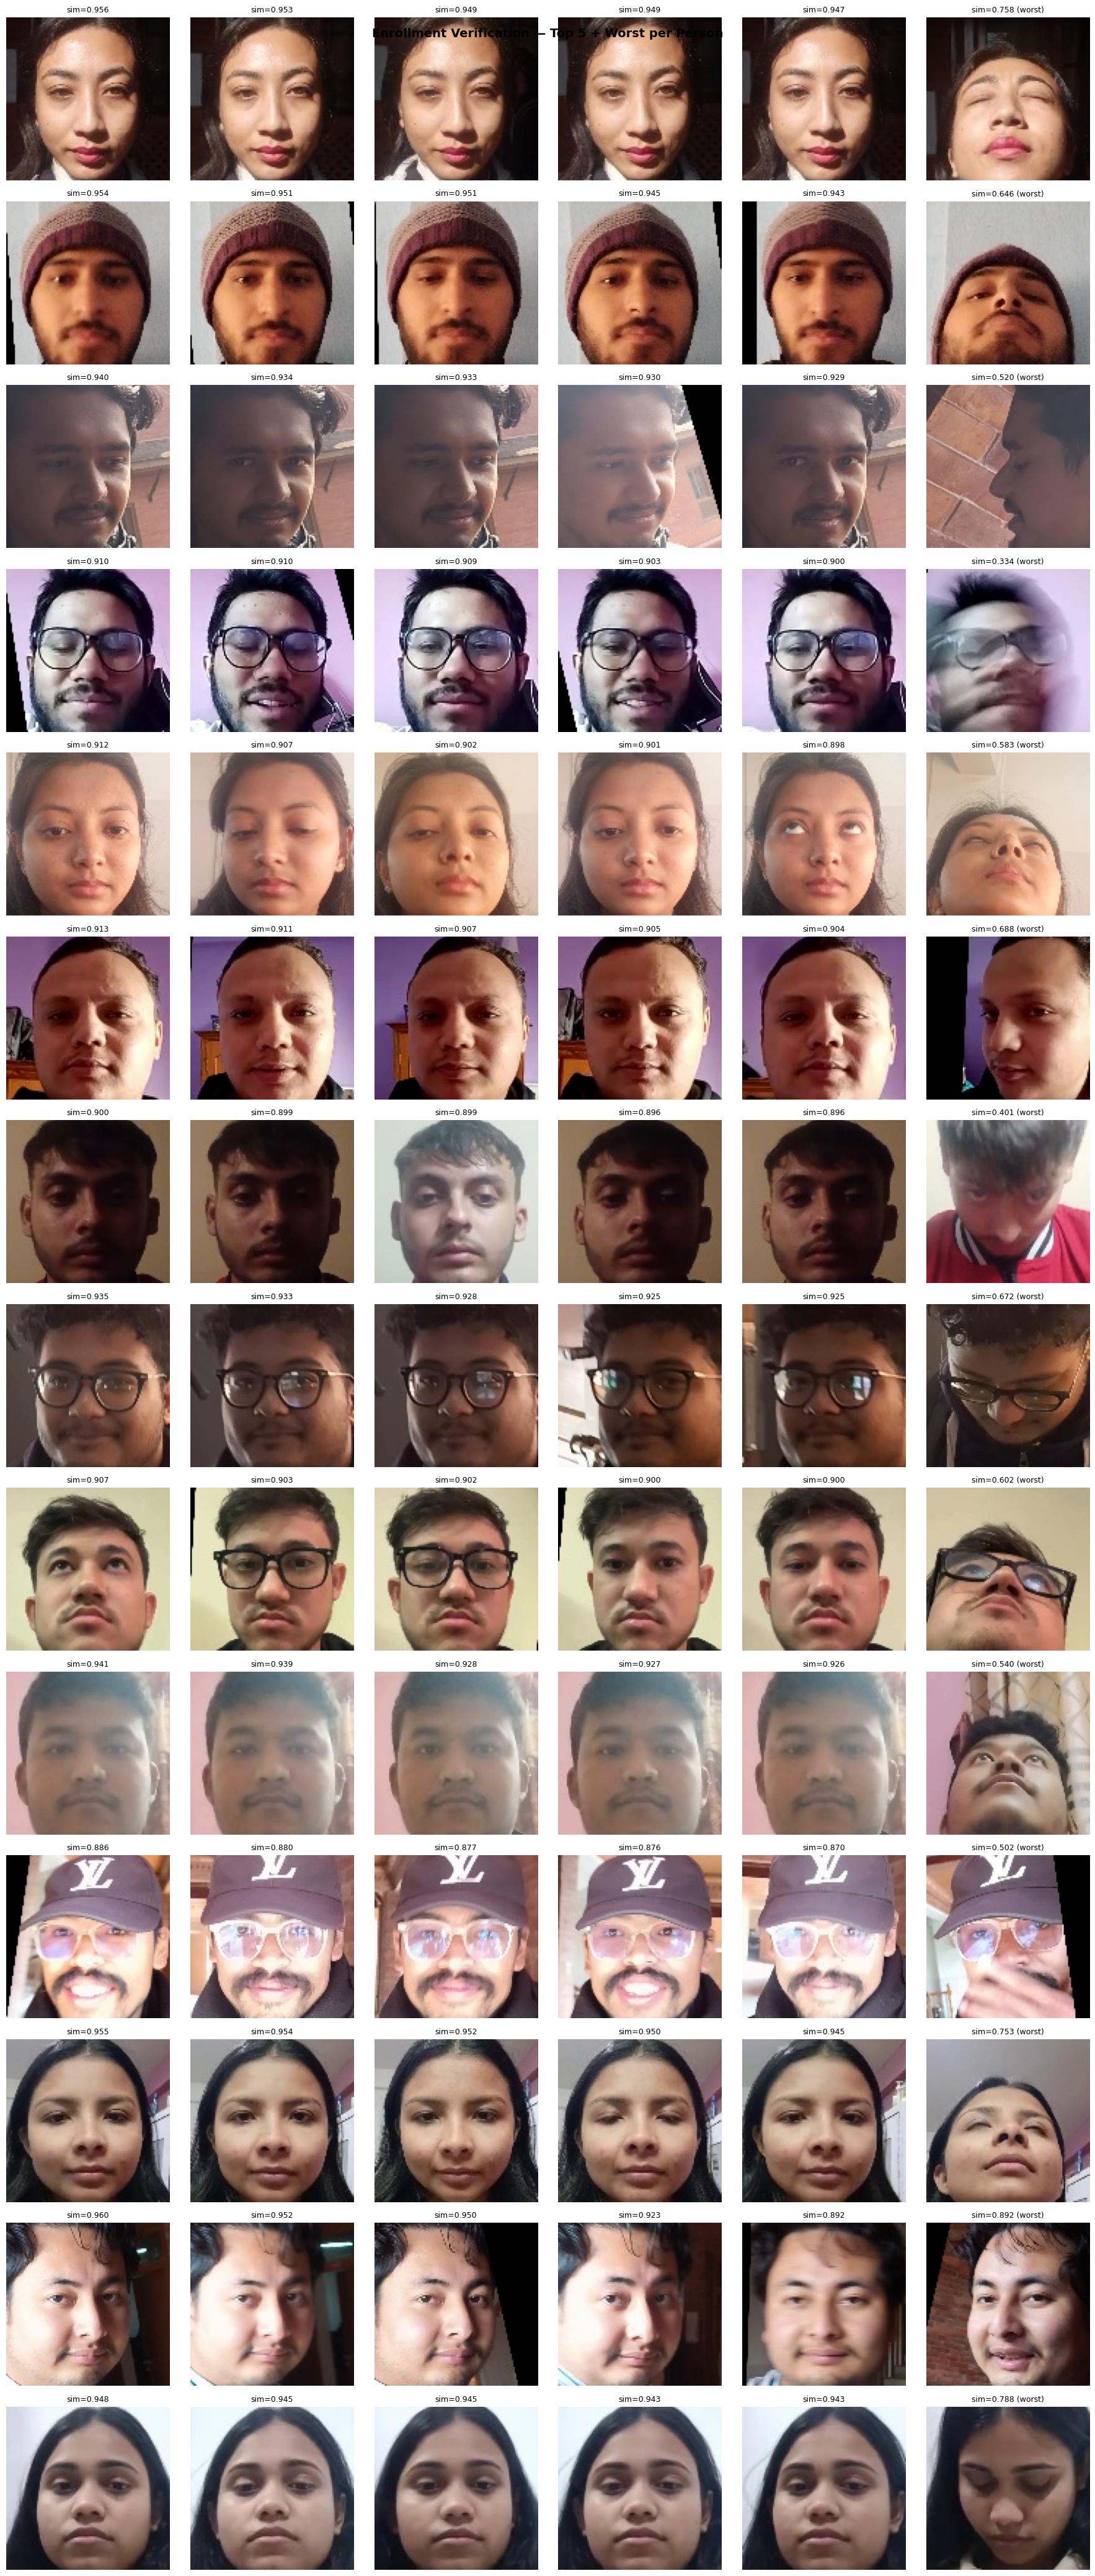


Per-person embedding quality:
  Person           Count   Mean Sim    Min Sim      Std
  ──────────────────────────────────────────────────
  780306              32     0.8867     0.7576   0.0592
  780309              23     0.8687     0.6459   0.0906
  780312              60     0.8611     0.5202   0.0943
  780314             112     0.8047     0.3335   0.1004
  780315              30     0.8099     0.5827   0.0949
  780317             147     0.8460     0.6877   0.0392
  780322              40     0.7615     0.4010   0.1470
  780324              50     0.8717     0.6721   0.0646
  780328              45     0.8228     0.6019   0.0865
  780339              61     0.8449     0.5405   0.0876
  780340              38     0.7972     0.5024   0.0767
  780341              28     0.8876     0.7531   0.0580
  780343               6     0.9281     0.8919   0.0280
  780349              35     0.8986     0.7883   0.0379


In [ ]:

# ╔════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — QUICK VERIFICATION (run after extraction)         ║
# ╚════════════════════════════════════════════════════════════════╝

def verify_extraction():
    """
    Quick visual + numeric check of extraction results.
    Shows sample faces and embedding quality per person.
    """
    import matplotlib.pyplot as plt

    if not os.path.exists(GALLERY_DIR):
        print("No gallery found — run extraction first.")
        return

    gallery_files = sorted([f for f in os.listdir(GALLERY_DIR)
                            if f.endswith('_gallery.npz')])

    n_persons = len(gallery_files)
    if n_persons == 0:
        print("No enrolled persons found.")
        return

    fig, axes = plt.subplots(n_persons, 6, figsize=(18, 3 * n_persons))
    if n_persons == 1:
        axes = [axes]

    for row, gf in enumerate(gallery_files):
        pid = gf.replace('_gallery.npz', '')
        data = np.load(os.path.join(GALLERY_DIR, gf))
        centroid = data['centroid']
        embs     = data['embeddings']

        # Compute similarities to centroid
        sims = embs @ centroid
        sorted_idx = np.argsort(-sims)  # best first

        face_dir = os.path.join(FACES_DIR, pid)
        if not os.path.exists(face_dir):
            continue

        face_files = sorted(os.listdir(face_dir))

        # Show top 5 + worst 1
        show_indices = list(sorted_idx[:5])
        if len(sorted_idx) > 5:
            show_indices.append(sorted_idx[-1])

        for col, idx in enumerate(show_indices[:6]):
            if idx < len(face_files):
                img_path = os.path.join(face_dir, face_files[idx])
                img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                axes[row][col].imshow(img)
                label = f"sim={sims[idx]:.3f}"
                if col == 5 and len(sorted_idx) > 5:
                    label += " (worst)"
                axes[row][col].set_title(label, fontsize=9)
            axes[row][col].axis('off')

        axes[row][0].set_ylabel(f"{pid}\n({len(embs)} faces)",
                                 fontsize=11, fontweight='bold', rotation=0,
                                 labelpad=80, va='center')

    plt.suptitle("Enrollment Verification — Top 5 + Worst per Person",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Numeric summary
    print("\nPer-person embedding quality:")
    print(f"  {'Person':<15} {'Count':>6} {'Mean Sim':>10} {'Min Sim':>10} {'Std':>8}")
    print(f"  {'─'*50}")
    for gf in gallery_files:
        pid = gf.replace('_gallery.npz', '')
        data = np.load(os.path.join(GALLERY_DIR, gf))
        sims = data['embeddings'] @ data['centroid']
        print(f"  {pid:<15} {len(sims):>6} {np.mean(sims):>10.4f} "
              f"{np.min(sims):>10.4f} {np.std(sims):>8.4f}")


verify_extraction()